# Taller Práctico de OMOP CDM con Python y OHDSI Eunomia
### Diplomado en Salud Digital y Ciencia de Datos en Salud — Universidad del Rosario

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jdposada/diplomado_urosario/blob/main/eunomia_omop_showcase_es.ipynb)

Este cuaderno interactivo introduce de forma práctica los conceptos fundamentales del **Modelo Común de Datos OMOP (OMOP CDM v5.4)** promovido por la comunidad internacional **OHDSI (Observational Health Data Sciences and Informatics)**.

---

### Objetivos del Taller
1. **Comprender la Arquitectura Centrada en el Paciente**: Estructura de las tablas clínicas (`PERSON`, `OBSERVATION_PERIOD`, `VISIT_OCCURRENCE`, `CONDITION_OCCURRENCE`, `DRUG_EXPOSURE`, `MEASUREMENT`).
2. **Dominar los Vocabularios Estandarizados de OHDSI**: Resolución de códigos fuente a conceptos estándar vía relaciones `'Maps to'` en `CONCEPT_RELATIONSHIP`.
3. **Pipeline ETL en 3 Fases**: Transformar registros clínicos heterogéneos y no estandarizados a tablas OMOP CDM siguiendo el estándar de la industria (**Prepped**, **Mapped**, **Keyed**) con validación oficial mediante `pyomop`.
4. **Definición de Cohortes y Analítica Clínica con DuckDB**: Extracción de una cohorte incidente con criterios de observación previa y perfilamiento de medicamentos concomitantes.
5. **Ejercicios Prácticos Interactivos**:
   - **Ejercicio 1**: Identificación visual de fecha índice y evaluación del período de observación previa en líneas de tiempo.
   - **Ejercicio 2**: Mapeo de vocabularios fuente y enrutamiento de dominio (*Domain Routing*) con `CONCEPT_RELATIONSHIP`.
   - **Ejercicio 3**: Detección de patrones de medicación concomitante previa al evento índice.


## 1. Configuración del Entorno y Carga del Dataset Eunomia

Ejecute la siguiente celda interactiva. El código detectará automáticamente si se encuentra en **Google Colab** o en un entorno local, instalará las dependencias necesarias de manera silenciosa (`duckdb`, `pyomop`, `pandas`, `seaborn`) y descargará el conjunto de datos de prueba **Eunomia** de OHDSI en memoria.


In [2]:
# @title Inicializar Entorno y Cargar Datos de Eunomia { display-mode: 'form' }
import sys
import subprocess
import os

# Detección automática de Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Entorno Google Colab detectado. Instalando dependencias requeridas...")
    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q",
        "duckdb==1.5.5", "pyomop==6.4.0", "certifi", "seaborn", "matplotlib"
    ], check=True)
    print("Dependencias instaladas exitosamente en Colab.")
else:
    print("Ejecutando en entorno local / Jupyter.")

import ssl
import glob
import zipfile
import urllib.request
import certifi
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyomop import cdm54

# Configuración de visualización de tablas
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 60)
sns.set_theme(style="whitegrid")

def cargar_eunomia_duckdb(directorio_cache: str = ".eunomia_data") -> duckdb.DuckDBPyConnection:
    """Descarga e ingesta los conjuntos de datos OHDSI Eunomia en una sesión DuckDB en memoria.

    1. GiBleed: 2,694 pacientes sintéticos longitudinales con registros clínicos completos.
    2. Synthea27Nj: Mapeos de vocabulario suplementarios (CONCEPT_RELATIONSHIP con 266k+ relaciones 'Maps to').
    """
    os.makedirs(directorio_cache, exist_ok=True)
    ctx = ssl.create_default_context(cafile=certifi.where())

    # 1. Dataset GiBleed (Eventos clínicos)
    gibleed_zip = os.path.join(directorio_cache, "GiBleed_5.3.zip")
    gibleed_dir = os.path.join(directorio_cache, "GiBleed_5.3")
    if not os.path.exists(gibleed_zip):
        print("Descargando dataset Eunomia GiBleed desde OHDSI...")
        url = "https://raw.githubusercontent.com/OHDSI/EunomiaDatasets/main/datasets/GiBleed/GiBleed_5.3.zip"
        req = urllib.request.Request(url, headers={"User-Agent": "Python/OMOP-Urosario"})
        with urllib.request.urlopen(req, context=ctx) as resp, open(gibleed_zip, "wb") as f:
            f.write(resp.read())

    if not os.path.exists(gibleed_dir):
        print("Extrayendo tablas de GiBleed...")
        with zipfile.ZipFile(gibleed_zip, "r") as z:
            z.extractall(directorio_cache)

    # 2. Dataset Synthea27Nj (Mapeos 'Maps to')
    synthea_zip = os.path.join(directorio_cache, "Synthea27Nj_5.4.zip")
    synthea_dir = os.path.join(directorio_cache, "Synthea27Nj_5.4")
    if not os.path.exists(synthea_zip):
        print("Descargando tablas de mapeo de vocabulario...")
        url = "https://raw.githubusercontent.com/OHDSI/EunomiaDatasets/main/datasets/Synthea27Nj/Synthea27Nj_5.4.zip"
        req = urllib.request.Request(url, headers={"User-Agent": "Python/OMOP-Urosario"})
        with urllib.request.urlopen(req, context=ctx) as resp, open(synthea_zip, "wb") as f:
            f.write(resp.read())

    if not os.path.exists(synthea_dir):
        print("Extrayendo tablas de vocabulario...")
        with zipfile.ZipFile(synthea_zip, "r") as z:
            z.extractall(synthea_dir)

    con = duckdb.connect()
    for f in sorted(glob.glob(f"{gibleed_dir}/*.csv")):
        tbl = os.path.basename(f).replace(".csv", "").lower()
        con.execute(f"create table {tbl} as select * from read_csv_auto('{f}', ignore_errors=true)")

    synth_cr = os.path.join(synthea_dir, "CONCEPT_RELATIONSHIP.csv")
    if os.path.exists(synth_cr):
        con.execute(f"""
            create table cr_synth as select * from read_csv_auto('{synth_cr}', ignore_errors=true);
            insert into concept_relationship
            select * from cr_synth
            where not exists (
                select 1 from concept_relationship cr
                where cr.concept_id_1 = cr_synth.concept_id_1
                  and cr.concept_id_2 = cr_synth.concept_id_2
                  and cr.relationship_id = cr_synth.relationship_id
            );
            drop table cr_synth;
        """)

    synth_c = os.path.join(synthea_dir, "CONCEPT.csv")
    if os.path.exists(synth_c):
        con.execute(f"""
            create table c_synth as select * from read_csv_auto('{synth_c}', ignore_errors=true);
            insert into concept
            select * from c_synth
            where not exists (
                select 1 from concept c
                where c.concept_id = c_synth.concept_id
            );
            drop table c_synth;
        """)

    return con

con = cargar_eunomia_duckdb()
print("Base de datos Eunomia OMOP CDM inicializada y lista en la sesión DuckDB.")


Entorno Google Colab detectado. Instalando dependencias requeridas...
Dependencias instaladas exitosamente en Colab.


Descargando dataset Eunomia GiBleed desde OHDSI...
Extrayendo tablas de GiBleed...
Descargando tablas de mapeo de vocabulario...
Extrayendo tablas de vocabulario...
Base de datos Eunomia OMOP CDM inicializada y lista en la sesión DuckDB.


In [3]:
# @title Explorador de Tablas del OMOP CDM { display-mode: 'form' }
# @markdown ### Inventario de Tablas del OMOP CDM
# @markdown Seleccione cuántas tablas desea visualizar en el resumen de filas:
max_tablas = 15  # @param {type:"slider", min:5, max:40, step:5}

inventario_df = con.execute(f"""
    select
        table_name as tabla_omop,
        estimated_size as total_filas
    from duckdb_tables()
    where table_name not like 'sqlite_%'
    order by total_filas desc
    limit {max_tablas}
""").df()

display(inventario_df)


,tabla_omop,total_filas
0,concept_relationship,266596
1,drug_exposure,67707
2,condition_era,65719
3,concept_ancestor,65690
4,condition_occurrence,65332
5,drug_era,52508
6,measurement,44053
7,procedure_occurrence,37409
8,observation_period,5343
9,person,2694


## 2. Recorrido por el Modelo OMOP CDM

El modelo OMOP CDM está estructurado alrededor de la persona:
* **`PERSON`**: Atributos demográficos basales inmutables (año de nacimiento, género, raza).
* **`OBSERVATION_PERIOD`**: Define la ventana de tiempo en la que el paciente fue observado activamente. En epidemiología observacional, esto fija el **denominador** poblacional.
* **Tablas de Eventos Clínicos**: Contactos (`VISIT_OCCURRENCE`), diagnósticos (`CONDITION_OCCURRENCE`), medicamentos (`DRUG_EXPOSURE`) y paraclínicos (`MEASUREMENT`).

Todas las tablas clínicas comparten columnas estandarizadas:
* `*_concept_id`: Identificador estándar de OHDSI.
* `*_source_value`: Texto o código original del registro médico.
* `*_type_concept_id`: Procedencia o tipo de registro (ej. diagnóstico de consulta externa vs. reclamo administrativo).


In [4]:
# @title Navegador Demográfico Interactivo { display-mode: 'form' }
# @markdown ### Filtro Demográfico de Pacientes
filtro_genero = "Todos"  # @param ["Todos", "MALE", "FEMALE"]
max_pacientes = 10  # @param {type:"slider", min:5, max:50, step:5}

clausula_where = ""
if filtro_genero != "Todos":
    clausula_where = f"where c_gen.concept_name = '{filtro_genero}'"

consulta_demo = f"""
    select
        p.person_id as id_paciente,
        coalesce(c_gen.concept_name, 'No especificado') as genero,
        p.year_of_birth as anio_nacimiento,
        coalesce(c_raza.concept_name, 'No especificado') as raza,
        op.observation_period_start_date as inicio_observacion,
        op.observation_period_end_date as fin_observacion,
        datediff('year', cast(op.observation_period_start_date as date), cast(op.observation_period_end_date as date)) as anios_observado
    from person p
    left join concept c_gen on p.gender_concept_id = c_gen.concept_id
    left join concept c_raza on p.race_concept_id = c_raza.concept_id
    left join observation_period op on p.person_id = op.person_id
    {clausula_where}
    order by p.person_id
    limit {max_pacientes}
"""

demo_df = con.execute(consulta_demo).df()
display(demo_df)


,id_paciente,genero,anio_nacimiento,raza,inicio_observacion,fin_observacion,anios_observado
0,1,MALE,1949,No especificado,1949-01-28,2019-05-24,70
1,2,FEMALE,1920,No especificado,1920-06-01,2008-03-25,88
2,3,MALE,1916,No especificado,1916-01-03,2018-10-29,102
3,5,MALE,1968,No especificado,1968-07-24,2018-08-29,50
4,6,FEMALE,1963,No especificado,1963-12-31,2007-02-06,44
5,7,FEMALE,1968,No matching concept,1968-11-06,2018-11-07,50
6,9,FEMALE,1978,No especificado,1978-07-20,2018-10-25,40
7,11,MALE,1953,No especificado,1953-02-03,2019-05-07,66
8,12,FEMALE,1963,No especificado,1963-01-30,2019-03-06,56
9,16,FEMALE,1971,No especificado,1971-10-14,2017-11-02,46


In [16]:
# @title Explorador Interactivo de Trayectoria del Paciente { display-mode: 'form' }
# @markdown ### Trayectoria Clínica Longitudinal de un Paciente
id_paciente_seleccionado = 6  # @param [6, 28, 43, 160, 207, 266, 5245] {type:"raw", allow-input: true}
filtro_dominio = "Todos"  # @param ["Todos", "VISIT", "CONDITION", "DRUG"]
max_eventos = 15  # @param {type:"slider", min:5, max:50, step:5}

where_dominio = ""
if filtro_dominio != "Todos":
    where_dominio = f"where dominio = '{filtro_dominio}'"

consulta_linea_tiempo = f"""
with todos_los_eventos as (
    select
        'VISIT' as dominio,
        vo.visit_start_date as fecha_evento,
        c_visita.concept_name as nombre_evento,
        vo.visit_source_value as valor_original_fuente,
        c_tipo.concept_name as procedencia_registro
    from visit_occurrence vo
    left join concept c_visita on vo.visit_concept_id = c_visita.concept_id
    left join concept c_tipo on vo.visit_type_concept_id = c_tipo.concept_id
    where vo.person_id = {id_paciente_seleccionado}

    union all

    select
        'CONDITION' as dominio,
        co.condition_start_date as fecha_evento,
        c_cond.concept_name as nombre_evento,
        co.condition_source_value as valor_original_fuente,
        c_tipo.concept_name as procedencia_registro
    from condition_occurrence co
    left join concept c_cond on co.condition_concept_id = c_cond.concept_id
    left join concept c_tipo on co.condition_type_concept_id = c_tipo.concept_id
    where co.person_id = {id_paciente_seleccionado}

    union all

    select
        'DRUG' as dominio,
        de.drug_exposure_start_date as fecha_evento,
        c_medicamento.concept_name as nombre_evento,
        de.drug_source_value as valor_original_fuente,
        c_tipo.concept_name as procedencia_registro
    from drug_exposure de
    left join concept c_medicamento on de.drug_concept_id = c_medicamento.concept_id
    left join concept c_tipo on de.drug_type_concept_id = c_tipo.concept_id
    where de.person_id = {id_paciente_seleccionado}
)
select * from todos_los_eventos
{where_dominio}
order by fecha_evento desc, dominio
limit {max_eventos}
"""

linea_tiempo_df = con.execute(consulta_linea_tiempo).df()
print(f"Historial longitudinal de eventos para el Paciente ID: {id_paciente_seleccionado}")
display(linea_tiempo_df)


Historial longitudinal de eventos para el Paciente ID: 6


,dominio,fecha_evento,nombre_evento,valor_original_fuente,procedencia_registro
0,DRUG,2006-01-10,"hepatitis A vaccine, adult dosage",52,None
1,DRUG,2006-01-10,"tetanus and diphtheria toxoids, adsorbed, preservative f...",113,None
2,CONDITION,2005-07-13,Osteoarthritis,396275006,None
3,DRUG,2005-07-13,celecoxib,00025152531,None
4,CONDITION,2005-06-17,Whiplash injury to neck,39848009,None
5,DRUG,2005-06-17,Naproxen sodium 220 MG Oral Tablet,849574,None
6,CONDITION,2004-05-09,Laceration of foot,284551006,None
7,DRUG,2004-05-09,Naproxen sodium 220 MG Oral Tablet,849574,None
8,DRUG,2004-01-06,"hepatitis A vaccine, adult dosage",52,None
9,CONDITION,2003-12-21,Seizure disorder,128613002,None


## 3. El Motor de Vocabularios Estandarizados y la Tabla `CONCEPT_RELATIONSHIP`

Los vocabularios estandarizados de OHDSI armonizan sistemas de codificación como CIE-10, SNOMED-CT, RxNorm y LOINC.

### 3.1 Estado de Estandarización (`standard_concept`)
En la tabla `CONCEPT`, la columna `standard_concept` clasifica el rol del concepto:
* `'S'` (**Estándar**): Concepto canónico para registrar hechos clínicos en las tablas de eventos.
* `'C'` (**Clasificación**): Clases de medicamentos o categorías de enfermedades para definir cohortes.
* `NULL` (**No estándar**): Códigos fuente (ej. CIE-10, CPT, NDC) que deben mapearse a un concepto estándar.

### 3.2 La Relación `'Maps to'` en `CONCEPT_RELATIONSHIP`
La tabla `CONCEPT_RELATIONSHIP` almacena millones de relaciones directas entre conceptos. Para estandarizar datos de salud, la relación principal es **`relationship_id = 'Maps to'`**:
* Toma el `concept_id_1` (código fuente no estándar) y lo enlaza con el `concept_id_2` (concepto estándar).
* Además, el `domain_id` del concepto destino fija el **Enrutamiento de Dominio** (*Domain Routing*).


In [6]:
# @title Buscador Interactivo de Conceptos y Vocabularios { display-mode: 'form' }
# @markdown ### Buscador de Conceptos Clínicos en el Vocabulario OMOP
termino_busqueda = "hemorrhage"  # @param {type:"string"}
filtro_vocabulario = "Todos"  # @param ["Todos", "SNOMED", "RxNorm", "LOINC", "ICD10CM"]
solo_conceptos_estandar = True  # @param {type:"boolean"}
max_resultados = 10  # @param {type:"slider", min:5, max:30, step:5}

condiciones = [f"lower(concept_name) like '%{termino_busqueda.lower()}%'"]
if filtro_vocabulario != "Todos":
    condiciones.append(f"vocabulary_id = '{filtro_vocabulario}'")
if solo_conceptos_estandar:
    condiciones.append("standard_concept = 'S'")

where_sql = "where " + " and ".join(condiciones)

consulta_conceptos = f"""
    select
        concept_id as id_concepto,
        concept_name as nombre_concepto,
        domain_id as dominio,
        vocabulary_id as vocabulario,
        concept_class_id as clase_concepto,
        coalesce(standard_concept, 'No estándar') as estatus_estandar
    from concept
    {where_sql}
    order by concept_name
    limit {max_resultados}
"""

conceptos_df = con.execute(consulta_conceptos).df()
display(conceptos_df)


,id_concepto,nombre_concepto,dominio,vocabulario,clase_concepto,estatus_estandar
0,192671,Gastrointestinal hemorrhage,Condition,SNOMED,Clinical Finding,S


In [7]:
# @title Navegador de Mapeos 'Maps to' en CONCEPT_RELATIONSHIP { display-mode: 'form' }
# @markdown ### Explorador de Relaciones 'Maps to' (Código Fuente a Concepto Estándar)
# @markdown Seleccione un vocabulario fuente para ver cómo sus conceptos no estándar traducen a conceptos estándar:
vocabulario_fuente = "ICD10CM"  # @param ["ICD10CM", "SNOMED", "LOINC", "RxNorm", "UCUM"]
limite_filas = 10  # @param {type:"slider", min:5, max:30, step:5}

consulta_mapeos = f"""
    select
        c_fuente.concept_code as codigo_fuente,
        c_fuente.concept_name as descripcion_fuente,
        c_fuente.vocabulary_id as vocab_fuente,
        cr.relationship_id as relacion,
        c_estandar.concept_id as id_concepto_estandar,
        c_estandar.concept_name as nombre_estandar,
        c_estandar.domain_id as dominio_destino,
        c_estandar.vocabulary_id as vocab_estandar
    from concept_relationship cr
    join concept c_fuente on cr.concept_id_1 = c_fuente.concept_id
    join concept c_estandar on cr.concept_id_2 = c_estandar.concept_id
    where cr.relationship_id = 'Maps to'
      and c_fuente.concept_id != c_estandar.concept_id
      and c_fuente.vocabulary_id = '{vocabulario_fuente}'
    order by c_fuente.concept_name
    limit {limite_filas}
"""

mapeos_df = con.execute(consulta_mapeos).df()
display(mapeos_df)


,codigo_fuente,descripcion_fuente,vocab_fuente,relacion,id_concepto_estandar,nombre_estandar,dominio_destino,vocab_estandar
0,K92.2,"Gastrointestinal hemorrhage, unspecified",ICD10CM,Maps to,192671,Gastrointestinal hemorrhage,Condition,SNOMED


## 4. Demostración Práctica de ETL: De Historia Clínica Cruda a OMOP CDM

En entornos de producción, la transformación ETL se ejecuta en 3 fases:
1. **Fase 1: Preparación (`prepped`)**: Limpieza de datos crudos, estandarización de fechas y generación de tablas puente (*crosswalks*) para identificadores de pacientes y atenciones.
2. **Fase 2: Mapeo y Enrutamiento (`mapped`)**: Resolución de códigos fuente a conceptos estándar mediante `CONCEPT_RELATIONSHIP` y **Enrutamiento de Dominios** (*Domain Routing*). Si un diagnóstico fuente mapea a un concepto con `domain_id = 'Observation'`, se enruta a `OBSERVATION` y no a `CONDITION_OCCURRENCE`.
3. **Fase 3: Generación de Llaves y Ensamble (`keyed`)**: Asignación de llaves subrogadas, metadatos de procedencia (`*_type_concept_id`) y verificación de conformidad con el esquema oficial de **`pyomop.cdm54`**.


In [8]:
# @title Ejecutar Pipeline de ETL en 3 Fases { display-mode: 'form' }
# @markdown ### Ejecución del Pipeline ETL OMOP
fase_a_mostrar = "Todas las Fases"  # @param ["Todas las Fases", "Fase 1: Preparacion (Prepped)", "Fase 2: Mapeo y Enrutamiento (Mapped)", "Fase 3: Generacion de Llaves y Validacion (Keyed)"]

# 1. Datos fuente simulados de Historia Clínica
pacientes_crudos = pd.DataFrame([
    {"historia_clinica": "HC-901", "genero_crudo": "Femenino", "fecha_nacimiento": "1978-04-15", "raza_cruda": "Blanca"},
    {"historia_clinica": "HC-902", "genero_crudo": "M", "fecha_nacimiento": "1965/08/20", "raza_cruda": "Asiática"},
    {"historia_clinica": "HC-903", "genero_crudo": "Desconocido", "fecha_nacimiento": "1982-11-03", "raza_cruda": "Otra"}
])

encuentros_crudos = pd.DataFrame([
    {"id_encuentro": "ENC-101", "historia_clinica": "HC-901", "fecha_atencion": "2023-05-10", "tipo_servicio": "Consulta Externa"},
    {"id_encuentro": "ENC-102", "historia_clinica": "HC-902", "fecha_atencion": "2023-06-15", "tipo_servicio": "Urgencias"},
    {"id_encuentro": "ENC-103", "historia_clinica": "HC-903", "fecha_atencion": "2023-07-01", "tipo_servicio": "Hospitalización"}
])

diagnosticos_crudos = pd.DataFrame([
    {"id_encuentro": "ENC-101", "historia_clinica": "HC-901", "fecha_dx": "2023-05-10", "codigo_cie10": "K92.2", "descripcion": "Hemorragia gastrointestinal, no especificada"},
    {"id_encuentro": "ENC-102", "historia_clinica": "HC-902", "fecha_dx": "2023-06-15", "codigo_cie10": "J01.90", "descripcion": "Sinusitis bacteriana aguda"},
    {"id_encuentro": "ENC-103", "historia_clinica": "HC-903", "fecha_dx": "2023-07-01", "codigo_cie10": "Z00.00", "descripcion": "Examen médico general de adulto"}
])

# --- FASE 1: PREPARACIÓN (PREPPED) ---
prep_pacientes = pacientes_crudos.copy()
prep_pacientes['fecha_nac_dt'] = pd.to_datetime(prep_pacientes['fecha_nacimiento'], format='mixed')
prep_pacientes['year_of_birth'] = prep_pacientes['fecha_nac_dt'].dt.year
prep_pacientes['month_of_birth'] = prep_pacientes['fecha_nac_dt'].dt.month
prep_pacientes['day_of_birth'] = prep_pacientes['fecha_nac_dt'].dt.day

# Crosswalk de Pacientes
mapa_person_id = {hc: 10001 + idx for idx, hc in enumerate(prep_pacientes['historia_clinica'].unique())}
prep_pacientes['person_id'] = prep_pacientes['historia_clinica'].map(mapa_person_id)

# Crosswalk de Encuentros
prep_encuentros = encuentros_crudos.copy()
prep_encuentros['person_id'] = prep_encuentros['historia_clinica'].map(mapa_person_id)
mapa_visit_id = {enc: 20001 + idx for idx, enc in enumerate(prep_encuentros['id_encuentro'].unique())}
prep_encuentros['visit_occurrence_id'] = prep_encuentros['id_encuentro'].map(mapa_visit_id)

# --- FASE 2: MAPEO Y ENRUTAMIENTO DE DOMINIO (MAPPED via CONCEPT_RELATIONSHIP) ---
diccionario_mapeo_dx = {
    "K92.2": {"target_concept_id": 192671, "nombre_estandar": "Gastrointestinal hemorrhage", "dominio": "Condition"},
    "J01.90": {"target_concept_id": 4294548, "nombre_estandar": "Acute bacterial sinusitis", "dominio": "Condition"},
    "Z00.00": {"target_concept_id": 4060000, "nombre_estandar": "General adult medical examination", "dominio": "Observation"}
}

dx_mapeados = diagnosticos_crudos.copy()
dx_mapeados['person_id'] = dx_mapeados['historia_clinica'].map(mapa_person_id)
dx_mapeados['visit_occurrence_id'] = dx_mapeados['id_encuentro'].map(mapa_visit_id)
dx_mapeados['concept_id_estandar'] = dx_mapeados['codigo_cie10'].map(lambda c: diccionario_mapeo_dx.get(c, {}).get("target_concept_id", 0))
dx_mapeados['dominio_destino'] = dx_mapeados['codigo_cie10'].map(lambda c: diccionario_mapeo_dx.get(c, {}).get("dominio", "Condition"))

# --- FASE 3: ENSAMBLE CDM Y VALIDACIÓN (KEYED) ---
registros_condicion = dx_mapeados[dx_mapeados['dominio_destino'] == 'Condition'].reset_index(drop=True)
cdm_condition_occurrence = pd.DataFrame({
    'condition_occurrence_id': [30001 + i for i in range(len(registros_condicion))],
    'person_id': registros_condicion['person_id'],
    'condition_concept_id': registros_condicion['concept_id_estandar'],
    'condition_start_date': pd.to_datetime(registros_condicion['fecha_dx']).dt.date,
    'condition_start_datetime': pd.to_datetime(registros_condicion['fecha_dx']),
    'condition_end_date': pd.to_datetime(registros_condicion['fecha_dx']).dt.date,
    'condition_end_datetime': pd.to_datetime(registros_condicion['fecha_dx']),
    'condition_type_concept_id': 32817, # Diagnóstico en atención EHR
    'condition_status_concept_id': 0,
    'stop_reason': None,
    'provider_id': None,
    'visit_occurrence_id': registros_condicion['visit_occurrence_id'],
    'visit_detail_id': None,
    'condition_source_value': registros_condicion['codigo_cie10'] + ': ' + registros_condicion['descripcion'],
    'condition_source_concept_id': 0,
    'condition_status_source_value': None
})

registros_observacion = dx_mapeados[dx_mapeados['dominio_destino'] == 'Observation'].reset_index(drop=True)
cdm_observation = pd.DataFrame({
    'observation_id': [40001 + i for i in range(len(registros_observacion))],
    'person_id': registros_observacion['person_id'],
    'observation_concept_id': registros_observacion['concept_id_estandar'],
    'observation_date': pd.to_datetime(registros_observacion['fecha_dx']).dt.date,
    'observation_datetime': pd.to_datetime(registros_observacion['fecha_dx']),
    'observation_type_concept_id': 32817,
    'value_as_number': None,
    'value_as_string': None,
    'value_as_concept_id': 0,
    'qualifier_concept_id': 0,
    'unit_concept_id': 0,
    'provider_id': None,
    'visit_occurrence_id': registros_observacion['visit_occurrence_id'],
    'visit_detail_id': None,
    'observation_source_value': registros_observacion['codigo_cie10'] + ': ' + registros_observacion['descripcion'],
    'observation_source_concept_id': 0,
    'unit_source_value': None,
    'qualifier_source_value': None,
    'value_source_value': None,
    'observation_event_id': None,
    'obs_event_field_concept_id': 0
})

if fase_a_mostrar in ["Todas las Fases", "Fase 1: Preparacion (Prepped)"]:
    print("=== FASE 1: PREPARACIÓN (Limpieza y Crosswalk de Pacientes) ===")
    display(prep_pacientes[['historia_clinica', 'person_id', 'fecha_nac_dt', 'year_of_birth']])

if fase_a_mostrar in ["Todas las Fases", "Fase 2: Mapeo y Enrutamiento (Mapped)"]:
    print("\n=== FASE 2: MAPEO Y ENRUTAMIENTO (Domain Routing) ===")
    display(dx_mapeados[['historia_clinica', 'codigo_cie10', 'descripcion', 'concept_id_estandar', 'dominio_destino']])

if fase_a_mostrar in ["Todas las Fases", "Fase 3: Generacion de Llaves y Validacion (Keyed)"]:
    print("\n=== FASE 3: TABLA CDM CONDITION_OCCURRENCE ===")
    display(cdm_condition_occurrence[['condition_occurrence_id', 'person_id', 'condition_concept_id', 'condition_start_date', 'condition_source_value']])
    print("\n=== FASE 3: TABLA CDM OBSERVATION (Enrutada desde Z00.00) ===")
    display(cdm_observation[['observation_id', 'person_id', 'observation_concept_id', 'observation_date', 'observation_source_value']])

    # Validación oficial con pyomop.cdm54
    co_esperadas = set([c.name for c in cdm54.ConditionOccurrence.__table__.columns])
    obs_esperadas = set([c.name for c in cdm54.Observation.__table__.columns])
    print("\n[Validación Oficial con pyomop.cdm54]")
    print(f"¿Columnas de CONDITION_OCCURRENCE válidas?: {set(cdm_condition_occurrence.columns).issubset(co_esperadas)}")
    print(f"¿Columnas de OBSERVATION válidas?: {set(cdm_observation.columns).issubset(obs_esperadas)}")


=== FASE 1: PREPARACIÓN (Limpieza y Crosswalk de Pacientes) ===


,historia_clinica,person_id,fecha_nac_dt,year_of_birth
0,HC-901,10001,1978-04-15,1978
1,HC-902,10002,1965-08-20,1965
2,HC-903,10003,1982-11-03,1982



=== FASE 2: MAPEO Y ENRUTAMIENTO (Domain Routing) ===


,historia_clinica,codigo_cie10,descripcion,concept_id_estandar,dominio_destino
0,HC-901,K92.2,"Hemorragia gastrointestinal, no especificada",192671,Condition
1,HC-902,J01.90,Sinusitis bacteriana aguda,4294548,Condition
2,HC-903,Z00.00,Examen médico general de adulto,4060000,Observation



=== FASE 3: TABLA CDM CONDITION_OCCURRENCE ===


,condition_occurrence_id,person_id,condition_concept_id,condition_start_date,condition_source_value
0,30001,10001,192671,2023-05-10,"K92.2: Hemorragia gastrointestinal, no especificada"
1,30002,10002,4294548,2023-06-15,J01.90: Sinusitis bacteriana aguda



=== FASE 3: TABLA CDM OBSERVATION (Enrutada desde Z00.00) ===


,observation_id,person_id,observation_concept_id,observation_date,observation_source_value
0,40001,10003,4060000,2023-07-01,Z00.00: Examen médico general de adulto



[Validación Oficial con pyomop.cdm54]
¿Columnas de CONDITION_OCCURRENCE válidas?: True
¿Columnas de OBSERVATION válidas?: True


## 5. Definición Interactiva de Cohortes y Analítica Clínica

En investigación clínica observacional, el diseño de un estudio comienza con la **Definición de la Cohorte**:
1. **Evento Índice**: Condición que marca el ingreso a la cohorte (ej. primera ocurrencia de Hemorragia Gastrointestinal, concepto `192671`).
2. **Criterio de Observación Previa Continua**: Requisito de cobertura mínima antes del evento índice (ej. $\ge 180$ días) para garantizar que el evento sea verdaderamente incidente.
3. **Medicamentos Concomitantes**: Exposición a fármacos activos en una ventana previa al evento índice (ej. antiinflamatorios no esteroideos - AINEs).


Condición de estudio: Hemorragia gastrointestinal (192671)
Criterio de observación previa continua: >= 180 días
Pacientes que califican en la cohorte: 479


,id_paciente,fecha_indice,inicio_obs,fin_obs,dias_obs_previa,YEAR_OF_BIRTH,edad_al_indice,genero
0,3,1958-01-29,1916-01-03,2018-10-29,15367,1916,42,MALE
1,32,1987-06-09,1943-10-27,2014-12-24,15931,1943,44,MALE
2,35,1997-07-25,1960-03-22,2018-12-25,13639,1960,37,FEMALE
3,61,2005-09-15,1968-01-21,2019-01-06,13752,1968,37,FEMALE
4,80,1974-10-27,1936-11-09,2019-04-15,13866,1936,38,MALE


/tmp/ipykernel_3340/604705383.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


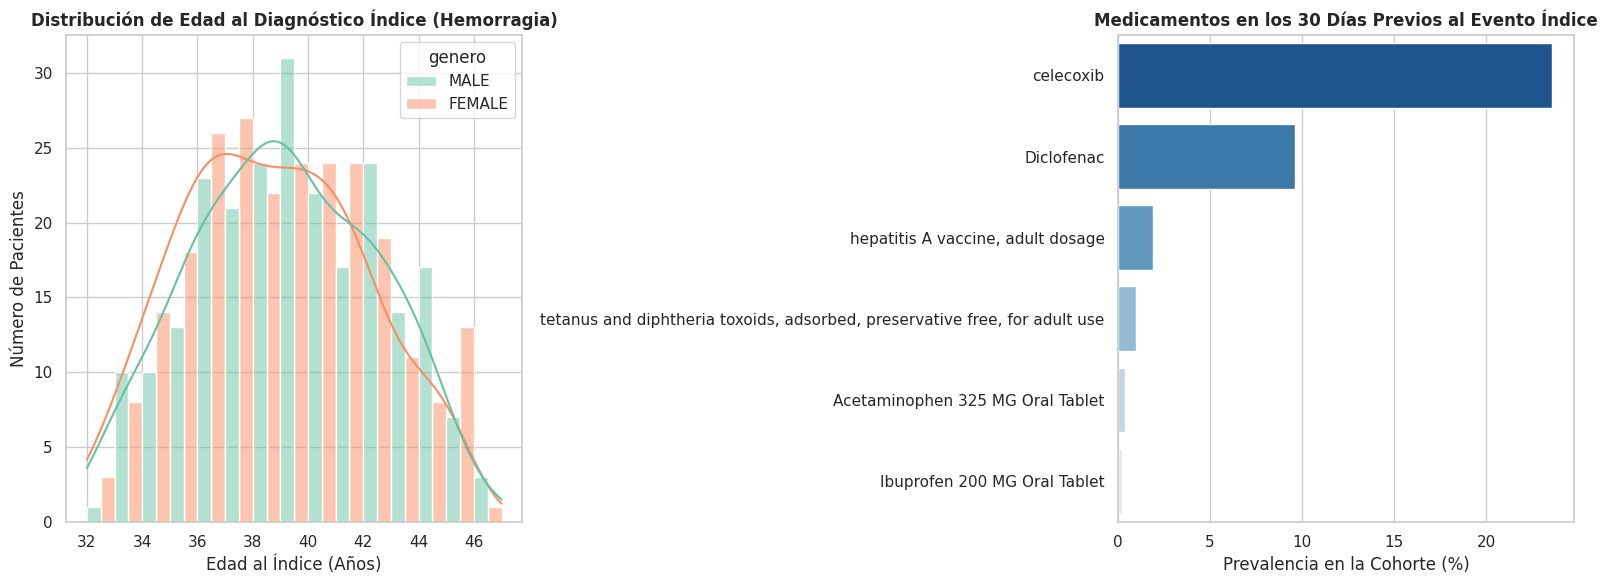

In [9]:
# @title Extracción de Cohorte y Perfil de Medicación Concomitante { display-mode: 'form' }
# @markdown ### Configuración de la Cohorte de Estudio
condicion_objetivo = "Hemorragia gastrointestinal (192671)"  # @param ["Hemorragia gastrointestinal (192671)", "Sinusitis (4283893)", "Faringitis viral aguda (4112343)"]
dias_observacion_previa = 180  # @param {type:"slider", min:0, max:365, step:30}
ventana_medicacion_dias = 30  # @param {type:"slider", min:14, max:90, step:7}

id_concepto_objetivo = int(condicion_objetivo.split("(")[-1].replace(")", ""))

sql_cohorte = f"""
with primer_evento as (
    select
        co.person_id,
        min(cast(co.condition_start_date as date)) as fecha_indice
    from condition_occurrence co
    where co.condition_concept_id = {id_concepto_objetivo}
    group by co.person_id
),
cohorte_calificada as (
    select
        f.person_id as id_paciente,
        f.fecha_indice,
        cast(op.observation_period_start_date as date) as inicio_obs,
        cast(op.observation_period_end_date as date) as fin_obs,
        datediff('day', cast(op.observation_period_start_date as date), f.fecha_indice) as dias_obs_previa,
        p.year_of_birth,
        date_part('year', f.fecha_indice) - p.year_of_birth as edad_al_indice,
        coalesce(c_gen.concept_name, 'No especificado') as genero
    from primer_evento f
    join observation_period op on f.person_id = op.person_id
      and f.fecha_indice between cast(op.observation_period_start_date as date) and cast(op.observation_period_end_date as date)
    join person p on f.person_id = p.person_id
    left join concept c_gen on p.gender_concept_id = c_gen.concept_id
    where datediff('day', cast(op.observation_period_start_date as date), f.fecha_indice) >= {dias_observacion_previa}
)
select * from cohorte_calificada
order by id_paciente
"""

cohorte_df = con.execute(sql_cohorte).df()
con.register('cohorte_activa', cohorte_df)

print(f"Condición de estudio: {condicion_objetivo}")
print(f"Criterio de observación previa continua: >= {dias_observacion_previa} días")
print(f"Pacientes que califican en la cohorte: {len(cohorte_df)}")
display(cohorte_df.head(5))

# Medicamentos concomitantes en la ventana de estudio
medicamentos_concomitantes_df = con.execute(f"""
    select
        c.concept_name as nombre_medicamento,
        count(distinct de.person_id) as total_pacientes,
        round(100.0 * count(distinct de.person_id) / nullif((select count(*) from cohorte_activa), 0), 1) as prevalencia_porcentaje
    from cohorte_activa q
    join drug_exposure de on q.id_paciente = de.person_id
    join concept c on de.drug_concept_id = c.concept_id
    where cast(de.drug_exposure_start_date as date) between (cast(q.fecha_indice as date) - interval {ventana_medicacion_dias} day) and cast(q.fecha_indice as date)
    group by c.concept_name
    order by total_pacientes desc
    limit 8
""").df()

# Gráficos de visualización analítica
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Distribución etaria por género
if not cohorte_df.empty:
    sns.histplot(
        data=cohorte_df,
        x='edad_al_indice',
        hue='genero',
        multiple='dodge',
        bins=15,
        kde=True,
        palette='Set2',
        ax=axes[0]
    )
    axes[0].set_title(f'Distribución de Edad al Diagnóstico Índice ({condicion_objetivo.split()[0]})', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Edad al Índice (Años)')
    axes[0].set_ylabel('Número de Pacientes')

# Gráfico 2: Medicamentos concomitantes más frecuentes
if not medicamentos_concomitantes_df.empty:
    sns.barplot(
        data=medicamentos_concomitantes_df,
        x='prevalencia_porcentaje',
        y='nombre_medicamento',
        palette='Blues_r',
        ax=axes[1]
    )
    axes[1].set_title(f'Medicamentos en los {ventana_medicacion_dias} Días Previos al Evento Índice', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Prevalencia en la Cohorte (%)')
    axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


---
## 6. Ejercicios Prácticos del Diplomado

A continuación, pondremos en práctica los conceptos de fecha índice, observación previa, relaciones de vocabulario `'Maps to'` y detección de exposiciones farmacológicas concomitantes.

---

### Ejercicio 1: Identificación Visual del Evento Índice y Período de Observación

En epidemiología observacional, para estudiar la incidencia de una enfermedad o la efectividad de un tratamiento, es crucial:
1. Identificar la **Fecha del Evento Índice** (primer registro de la condición bajo estudio).
2. Verificar que el paciente cumpla con una **Ventana de Observación Previa Continua** (ej. $\ge 180$ días antes del índice) para descartar que sea un caso prevalente no documentado.

**Consigna**:
Observe la gráfica que compara las líneas de tiempo de dos pacientes frente al diagnóstico de **Faringitis viral aguda (Concept ID: `4112343`)**.
* **Paciente A (ID 207)**: Observe cuándo inicia su período de observación y cuándo ocurre su primer diagnóstico.
* **Paciente B (ID 6)**: Observe cuándo inicia su período de observación y cuándo ocurre su primer diagnóstico.

Responda:
1. *¿Cuál es la fecha del evento índice para el Paciente A y para el Paciente B?*
2. *¿Cuántos días de observación previa continua tuvo cada paciente antes de su evento índice?*
3. *Si el protocolo exige un mínimo de 180 días de observación previa, ¿cuál de los dos pacientes califica para ingresar a la cohorte del estudio?*


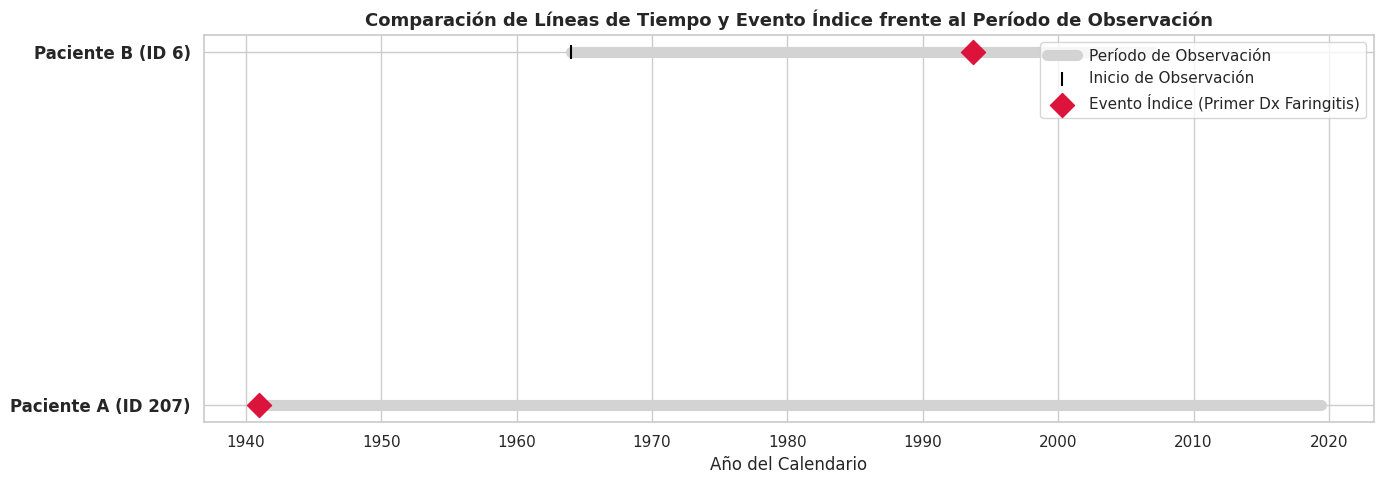

Resumen numérico de eventos:


,person_id,inicio_obs,fecha_primer_dx,dias_obs_previa
0,207,1940-10-21,1940-12-20,60
1,6,1963-12-31,1993-09-27,10863



    -----------------------------------------------------------------------------------
    RESPUESTA Y ANÁLISIS CLÍNICO:
    1. Paciente A (ID 207):
       - Inicio de observación: 1940-10-21 | Fecha evento índice: 1940-12-20.
       - Días de observación previa: 60 días.
       - Criterio de 180 días: NO CUMPLE. El diagnóstico ocurrió solo 2 meses después de ingresar
         al sistema de salud; no es posible asegurar que se trate de un caso nuevo (incidente).
         
    2. Paciente B (ID 6):
       - Inicio de observación: 1963-12-31 | Fecha evento índice: 1993-09-27.
       - Días de observación previa: 10,863 días (~29 años).
       - Criterio de 180 días: CUMPLE AMPLIAMENTE. Cumple el criterio para entrar a la cohorte.
    -----------------------------------------------------------------------------------


In [19]:
# @title Ejercicio 1: Gráfica de Línea de Tiempo y Evento Índice { display-mode: 'form' }
# @markdown ### Ejecutar Visualización de Líneas de Tiempo (Paciente A vs. Paciente B)
mostrar_solucion = True  # @param {type:"boolean"}

# Consultar datos de ambos pacientes para el diagnóstico de Faringitis (4112343)
consulta_lineas = """
select
    p.person_id as person_id,
    op.observation_period_start_date as inicio_obs,
    op.observation_period_end_date as fin_obs,
    min(co.condition_start_date) as fecha_primer_dx,
    datediff('day', cast(op.observation_period_start_date as date), cast(min(co.condition_start_date) as date)) as dias_obs_previa
from person p
join observation_period op on p.person_id = op.person_id
join condition_occurrence co on p.person_id = co.person_id
where p.person_id in (207, 6) and co.condition_concept_id = 4112343
group by p.person_id, op.observation_period_start_date, op.observation_period_end_date
order by p.person_id desc
"""
df_ej1 = con.execute(consulta_lineas).df()
df_ej1.columns = [c.lower() for c in df_ej1.columns]

fig, ax = plt.subplots(figsize=(14, 5))

colores_pacientes = {207: '#1f77b4', 6: '#2ca02c'}
nombres = {207: 'Paciente A (ID 207)', 6: 'Paciente B (ID 6)'}

for idx, fila in df_ej1.iterrows():
    pid = fila['person_id']
    y_pos = 1 if pid == 207 else 2

    # Línea del período de observación
    ax.plot(
        [pd.to_datetime(fila['inicio_obs']), pd.to_datetime(fila['fin_obs'])],
        [y_pos, y_pos],
        color='lightgray',
        lw=8,
        solid_capstyle='round',
        label='Período de Observación' if idx == 0 else ""
    )

    # Marcador de inicio de observación
    ax.scatter(
        [pd.to_datetime(fila['inicio_obs'])],
        [y_pos],
        color='black',
        s=90,
        marker='|',
        zorder=4,
        label='Inicio de Observación' if idx == 0 else ""
    )

    # Marcador del evento índice
    ax.scatter(
        [pd.to_datetime(fila['fecha_primer_dx'])],
        [y_pos],
        color='crimson',
        s=150,
        marker='D',
        zorder=5,
        label='Evento Índice (Primer Dx Faringitis)' if idx == 0 else ""
    )

ax.set_yticks([1, 2])
ax.set_yticklabels(['Paciente A (ID 207)', 'Paciente B (ID 6)'], fontsize=12, fontweight='bold')
ax.set_title('Comparación de Líneas de Tiempo y Evento Índice frente al Período de Observación', fontsize=13, fontweight='bold')
ax.set_xlabel('Año del Calendario')
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

print("Resumen numérico de eventos:")
display(df_ej1[['person_id', 'inicio_obs', 'fecha_primer_dx', 'dias_obs_previa']])

if mostrar_solucion:
    print("""
    -----------------------------------------------------------------------------------
    RESPUESTA Y ANÁLISIS CLÍNICO:
    1. Paciente A (ID 207):
       - Inicio de observación: 1940-10-21 | Fecha evento índice: 1940-12-20.
       - Días de observación previa: 60 días.
       - Criterio de 180 días: NO CUMPLE. El diagnóstico ocurrió solo 2 meses después de ingresar
         al sistema de salud; no es posible asegurar que se trate de un caso nuevo (incidente).

    2. Paciente B (ID 6):
       - Inicio de observación: 1963-12-31 | Fecha evento índice: 1993-09-27.
       - Días de observación previa: 10,863 días (~29 años).
       - Criterio de 180 días: CUMPLE AMPLIAMENTE. Cumple el criterio para entrar a la cohorte.
    -----------------------------------------------------------------------------------""")


---
### Ejercicio 2: Mapeo y Enrutamiento de Vocabulario Fuente (`CONCEPT_RELATIONSHIP`)

En este ejercicio explorará cómo los códigos no estándar de la historia clínica se transforman a conceptos estándar y cómo su dominio decide la tabla OMOP de destino.

**Consigna**:
1. Escriba o seleccione un código fuente (por ejemplo, el código CIE-10 `K92.2`, `J01.90` o `Z00.00`).
2. Consulte el websote the [OHDSI Athena](https://athena.ohdsi.org)
3. Verifique el `domain_id` del concepto destino:
   - Si `domain_id = 'Condition'`, ¿en qué tabla debe guardarse el registro?
   - Si `domain_id = 'Observation'`, ¿en qué tabla debe guardarse?
   - Si `domain_id = 'Procedure'`, ¿en qué tabla debe guardarse?


In [11]:
# @title Ejercicio 2: Mapeo y Enrutamiento con CONCEPT_RELATIONSHIP { display-mode: 'form' }
# @markdown ### Consultar Mapeo y Dominio de Destino para Códigos Fuente
codigo_a_consultar = "K92.2"  # @param ["K92.2", "J01.90", "Z00.00", "00093-0174-01"] {type:"raw", allow-input: true}
mostrar_explicacion = False  # @param {type:"boolean"}

consulta_ej2 = f"""
select
    c_fuente.concept_id as id_fuente,
    c_fuente.concept_code as codigo_fuente,
    c_fuente.concept_name as descripcion_fuente,
    c_fuente.vocabulary_id as vocab_fuente,
    cr.relationship_id as tipo_relacion,
    c_est.concept_id as id_concepto_estandar,
    c_est.concept_name as nombre_concepto_estandar,
    c_est.domain_id as dominio_destino,
    c_est.vocabulary_id as vocab_estandar
from concept c_fuente
join concept_relationship cr on c_fuente.concept_id = cr.concept_id_1
join concept c_est on cr.concept_id_2 = c_est.concept_id
where c_fuente.concept_code = '{codigo_a_consultar}'
  and cr.relationship_id = 'Maps to'
"""

res_ej2 = con.execute(consulta_ej2).df()
if not res_ej2.empty:
    display(res_ej2)
    dominio = res_ej2['dominio_destino'].iloc[0]
    tabla_omop = {
        'Condition': 'CONDITION_OCCURRENCE',
        'Observation': 'OBSERVATION',
        'Procedure': 'PROCEDURE_OCCURRENCE',
        'Measurement': 'MEASUREMENT',
        'Drug': 'DRUG_EXPOSURE'
    }.get(dominio, f"{dominio.upper()} (tabla correspondiente)")
    print(f"\n--> CONCLUSIÓN DE ENRUTAMIENTO: El dominio '{dominio}' exige que este registro se inserte en la tabla: {tabla_omop}")
else:
    print(f"No se encontró un mapeo directo 'Maps to' para el código '{codigo_a_consultar}'. En un ETL de producción, esto generaría concept_id = 0 preservando el texto en *_source_value.")

if mostrar_explicacion:
    print("""
    -----------------------------------------------------------------------------------
    REGLA DE ORO DE OHDSI (DOMAIN ROUTING):
    A diferencia de una base de datos relacional tradicional donde un diagnóstico siempre va a
    la tabla de 'diagnósticos', en OMOP CDM es el DOMINIO DEL CONCEPTO ESTÁNDAR DESTINO
    el que decide la tabla final.
    Ejemplo:
    - Código CIE-10 'Z00.00' (Examen médico general): Es un código diagnóstico en el EHR, pero
      su concepto estándar SNOMED (4060000) tiene domain_id = 'Observation'.
      Por lo tanto, DEBE insertarse en la tabla OBSERVATION y NUNCA en CONDITION_OCCURRENCE.
    -----------------------------------------------------------------------------------""")


,id_fuente,codigo_fuente,descripcion_fuente,vocab_fuente,tipo_relacion,id_concepto_estandar,nombre_concepto_estandar,dominio_destino,vocab_estandar
0,35208414,K92.2,"Gastrointestinal hemorrhage, unspecified",ICD10CM,Maps to,192671,Gastrointestinal hemorrhage,Condition,SNOMED



--> CONCLUSIÓN DE ENRUTAMIENTO: El dominio 'Condition' exige que este registro se inserte en la tabla: CONDITION_OCCURRENCE


---
### Ejercicio 3: Detección de Fármacos Concomitantes Previos al Evento Índice

En farmacovigilancia y estudios de seguridad de medicamentos, se analiza la exposición previa a fármacos que puedan estar asociados al desenlace clínico.

**Consigna**:
En la cohorte de pacientes con **Hemorragia Gastrointestinal (`192671`)**:
1. Ejecute la consulta para ver qué medicamentos recibieron los pacientes en los 30 días previos a la fecha del sangrado.
2. Identifique los dos fármacos con mayor prevalencia en la cohorte.
3. *¿Qué clase terapéutica comparten estos fármacos y por qué existe una justificación biológica conocida para este hallazgo?*


,medicamento,n_pacientes,prevalencia_pct
0,celecoxib,113,23.6
1,Diclofenac,46,9.6
2,"hepatitis A vaccine, adult dosage",9,1.9
3,"tetanus and diphtheria toxoids, adsorbed, preservative f...",5,1.0
4,Acetaminophen 325 MG Oral Tablet,2,0.4


/tmp/ipykernel_3340/744833652.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ej3, x='prevalencia_pct', y='medicamento', palette='Reds_r')


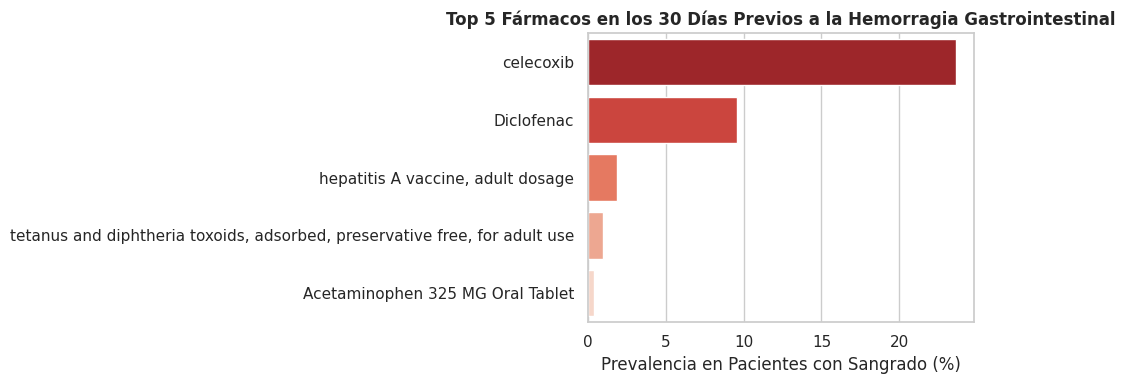

In [12]:
# @title Ejercicio 3: Farmacovigilancia y Exposición Concomitante { display-mode: 'form' }
# @markdown ### Analizar Fármacos Concomitantes en la Cohorte de Hemorragia Digestiva
dias_ventana = 30  # @param {type:"slider", min:15, max:60, step:15}
top_n = 5  # @param {type:"slider", min:3, max:10, step:1}
mostrar_discusion_clinica = False  # @param {type:"boolean"}

consulta_ej3 = f"""
with cohorte_gi as (
    select
        co.person_id as id_paciente,
        min(cast(co.condition_start_date as date)) as fecha_indice
    from condition_occurrence co
    where co.condition_concept_id = 192671 -- Hemorragia gastrointestinal
    group by co.person_id
),
medicamentos_previos as (
    select
        c.concept_name as medicamento,
        count(distinct de.person_id) as n_pacientes,
        round(100.0 * count(distinct de.person_id) / (select count(*) from cohorte_gi), 1) as prevalencia_pct
    from cohorte_gi g
    join drug_exposure de on g.id_paciente = de.person_id
    join concept c on de.drug_concept_id = c.concept_id
    where cast(de.drug_exposure_start_date as date) between (g.fecha_indice - interval {dias_ventana} day) and g.fecha_indice
    group by c.concept_name
    order by n_pacientes desc
    limit {top_n}
)
select * from medicamentos_previos
"""

df_ej3 = con.execute(consulta_ej3).df()
display(df_ej3)

# Gráfico del ejercicio 3
plt.figure(figsize=(10, 4))
sns.barplot(data=df_ej3, x='prevalencia_pct', y='medicamento', palette='Reds_r')
plt.title(f'Top {top_n} Fármacos en los {dias_ventana} Días Previos a la Hemorragia Gastrointestinal', fontsize=12, fontweight='bold')
plt.xlabel('Prevalencia en Pacientes con Sangrado (%)')
plt.ylabel('')
plt.tight_layout()
plt.show()

if mostrar_discusion_clinica:
    print("""
    -----------------------------------------------------------------------------------
    DISCUSIÓN CLÍNICA Y FARMACOLÓGICA:
    1. Los dos fármacos más frecuentes son Celecoxib (~23.6%) y Diclofenaco (~9.6%).
    2. Clase terapéutica: Ambos son Antiinflamatorios No Esteroideos (AINEs).
    3. Mecanismo Biológico: Los AINEs inhiben la enzima ciclooxigenasa (COX-1 y/o COX-2),
       reduciendo la síntesis de prostaglandinas protectoras de la mucosa gástrica e
       inhibiendo la agregación plaquetaria, lo cual incrementa notablemente el riesgo
       de úlcera péptica y hemorragia digestiva.
    4. Conclusión en OMOP: Mediante consultas relacionales estándar combinando tablas clínicas
       (CONDITION_OCCURRENCE, DRUG_EXPOSURE) y de vocabulario (CONCEPT), es posible generar
       evidencia del mundo real (RWE) sobre seguridad de medicamentos con reproducibilidad total.
    -----------------------------------------------------------------------------------""")


## 7. Resumen y Buenas Prácticas en el Ecosistema OHDSI

### Puntos Clave para Recordar:
1. **Desacoplamiento entre Esquema y Vocabularios**: En OMOP, las tablas no cambian cuando las guías clínicas o sistemas de codificación se actualizan. La columna `*_concept_id` estandariza el significado clínico a nivel global.
2. **Enrutamiento por Dominio (*Domain Routing*)**: La relación `'Maps to'` de la tabla `CONCEPT_RELATIONSHIP` vincula códigos locales a conceptos estándar, y el `domain_id` de destino decide en qué tabla clínica se almacena el dato.
3. **Periodos de Observación y Denominadores**: Siempre debe exigirse un periodo de observación previo (ej. 180 o 365 días) para distinguir eventos verdaderamente incidentes de antecedentes preexistentes.
4. **Portabilidad y Analítica Ligera con DuckDB**: Con herramientas embebidas como DuckDB, es posible ejecutar analítica avanzada sobre modelos OMOP directamente en Google Colab o computadores portátiles con paridad SQL total frente a BigQuery o PostgreSQL.
